# July 1 open-cluster membership enrichment

This notebook visualizes the exact-Gaia-ID UCC and Hunt--Reffert crossmatch for the July 1 MALCA cohort. It keeps catalog membership distinct from nearest-cluster proximity and treats the matched case--control analysis as the primary inferential result.

The notebook reads immutable sidecars produced by `malca open-cluster-backfill` and `malca open-cluster-test`, plus the saved 67,095-source July 1 run population used for the age-bin denominator. It opens the Review database read-only and does not modify catalog, candidate, or review data. Publication PDFs are written under `output/pdf/open_cluster_membership/`; notebook PNGs and audit tables are written under `output/notebooks/open_cluster_membership_enrichment/`.

In [1]:
from __future__ import annotations

import json
import math
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/malca-open-cluster-mpl")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LogNorm
from matplotlib.ticker import PercentFormatter
from scipy.stats import norm, spearmanr

from malca.enrichment.open_clusters import add_open_cluster_context
from malca.evaluation.open_cluster_enrichment import (
    load_review_labels,
    prepare_case_control_population,
)
from malca.io.lightcurve_io import load_lightcurve_df
from malca.io.notebook_paths import find_repo_root, resolve_local_lightcurve_path
from malca.io.table_io import read_feature_table
from malca.plotting.lightcurve_publication import PUBLICATION_STYLE, plot_lightcurve_panel
from malca.products.feature_layers import expand_feature_layers

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 80)

In [2]:
ROOT = find_repo_root(Path.cwd().resolve())
TAG = "july1_20260809_ucc_hr24_v1"
ANALYSIS_ROOT = ROOT / "output/evaluation/open_cluster_membership" / TAG
MEMBERSHIP_PATH = ANALYSIS_ROOT / "source_membership.parquet"
MATCHED_PATH = ANALYSIS_ROOT / "matched_test/matched_control_sets.parquet"
STATS_PATH = ANALYSIS_ROOT / "matched_test/membership_enrichment_statistics.csv"
MATCH_SUMMARY_PATH = ANALYSIS_ROOT / "matched_test/membership_enrichment_summary.json"
CATALOG_MANIFEST_PATH = ANALYSIS_ROOT / "catalog_manifest.json"
REVIEW_DB = ROOT / "output/runs/dat3-full-extended_2026-07-01-v4/review/review.db"
RUN_ROOT = REVIEW_DB.parents[1]
FULL_RUN_POPULATION_PATH = RUN_ROOT / "results/lc_events_filtered_all.parquet"
UCC_DIR = ROOT / "data/external/open_clusters/ucc/260615"
OUTPUT_ROOT = ROOT / "output/notebooks/open_cluster_membership_enrichment" / TAG
PDF_OUTPUT_ROOT = ROOT / "output/pdf/open_cluster_membership" / TAG
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
PDF_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

required_paths = [
    MEMBERSHIP_PATH, MATCHED_PATH, STATS_PATH, MATCH_SUMMARY_PATH,
    CATALOG_MANIFEST_PATH, REVIEW_DB, FULL_RUN_POPULATION_PATH, UCC_DIR,
]
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required open-cluster artifacts: " + ", ".join(missing))

print({"analysis_root": str(ANALYSIS_ROOT), "output_root": str(OUTPUT_ROOT)})

{'analysis_root': '/Users/calder/code/malca/output/evaluation/open_cluster_membership/july1_20260809_ucc_hr24_v1', 'output_root': '/Users/calder/code/malca/output/notebooks/open_cluster_membership_enrichment/july1_20260809_ucc_hr24_v1'}


## Load and audit the saved analysis

The Review database contributes labels only. Matching covariates and membership flags come from the saved source-level product; the matched-set file fixes which controls belong to each case.

In [3]:
membership = read_feature_table(MEMBERSHIP_PATH)
matched = pd.read_parquet(MATCHED_PATH)
statistics = pd.read_csv(STATS_PATH)
labels = load_review_labels(REVIEW_DB)
population = prepare_case_control_population(membership, labels)
match_summary = json.loads(MATCH_SUMMARY_PATH.read_text(encoding="utf-8"))
catalog_manifest = json.loads(CATALOG_MANIFEST_PATH.read_text(encoding="utf-8"))

assert len(membership) == catalog_manifest["output_rows"] == 22_942
assert membership["candidate_id"].astype(str).is_unique
assert matched.loc[matched["match_role"].eq("case"), "match_set_id"].is_unique
assert set(statistics["outcome"]) == {
    "ucc_good_member", "hr24_bound_member", "hr24_high_quality_member"
}

audit = pd.Series({
    "MALCA sources": len(membership),
    "reviewed sources with labels": len(population),
    "reviewed dippers": int(population["is_case"].sum()),
    "matching-eligible dippers": int((population["is_case"] & population["match_eligible"]).sum()),
    "matched dippers": int(matched["match_role"].eq("case").sum()),
    "matched controls": int(matched["match_role"].eq("control").sum()),
    "UCC listed members": int(membership["ucc_listed_member"].fillna(False).sum()),
    "UCC good members": int(membership["ucc_good_member"].fillna(False).sum()),
    "H&R listed members": int(membership["hr24_listed_member"].fillna(False).sum()),
    "H&R bound members": int(membership["hr24_bound_member"].fillna(False).sum()),
    "H&R high-quality members": int(membership["hr24_high_quality_member"].fillna(False).sum()),
}, name="count")
display(audit.to_frame())
display(statistics)

,count
MALCA sources,22942
reviewed sources with labels,2424
reviewed dippers,183
matching-eligible dippers,181
matched dippers,126
matched controls,321
UCC listed members,276
UCC good members,222
H&R listed members,265
H&R bound members,217


,outcome,match_sets,cases,controls,case_positive,control_positive,case_rate,control_rate,matched_rate_difference,mantel_haenszel_odds_ratio,bootstrap_ci95_low,bootstrap_ci95_high,bootstrap_finite_draws,matched_permutation_p,matched_permutation_draws,unadjusted_fisher_odds_ratio,unadjusted_fisher_p
0,ucc_good_member,126,126,321,17,12,0.134921,0.037383,0.080026,3.268519,1.418990,8.645994,1999,0.005099,10000,4.016055,0.000421
1,hr24_bound_member,126,126,321,14,14,0.111111,0.043614,0.051587,2.164751,0.956206,5.395403,2000,0.092691,10000,2.741071,0.015030
2,hr24_high_quality_member,126,126,321,13,11,0.103175,0.034268,0.051587,2.465438,1.023020,6.578106,2000,0.070293,10000,3.242156,0.008341


In [4]:
tab10 = plt.get_cmap("tab10")
COLOR_CASE = tab10(1)
COLOR_CONTROL = tab10(0)
COLOR_UCC = tab10(2)
COLOR_HR = tab10(4)
COLOR_HQ = tab10(3)
COLOR_NEUTRAL = "0.55"

OUTCOME_LABELS = {
    "ucc_good_member": "Reliable UCC",
    "hr24_bound_member": "H\&R bound",
    "hr24_high_quality_member": "H\&R high quality",
}

def boolean(frame: pd.DataFrame, column: str) -> pd.Series:
    return frame[column].fillna(False).astype(bool)


def save_figure(figure: plt.Figure, stem: str) -> dict[str, str]:
    pdf = OUTPUT_ROOT / f"{stem}.pdf"
    png = OUTPUT_ROOT / f"{stem}.png"
    figure.savefig(pdf, bbox_inches="tight")
    figure.savefig(png, dpi=300, bbox_inches="tight")
    return {"pdf": str(pdf), "png": str(png)}


def wilson_interval(positive: int, total: int, alpha: float = 0.05) -> tuple[float, float]:
    if total <= 0:
        return np.nan, np.nan
    z = float(norm.ppf(1.0 - alpha / 2.0))
    p = positive / total
    denominator = 1.0 + z**2 / total
    center = (p + z**2 / (2.0 * total)) / denominator
    half = z * np.sqrt(p * (1.0 - p) / total + z**2 / (4.0 * total**2)) / denominator
    return center - half, center + half


def standardized_difference(case: pd.Series, control: pd.Series) -> float:
    left = pd.to_numeric(case, errors="coerce").dropna().to_numpy(dtype=float)
    right = pd.to_numeric(control, errors="coerce").dropna().to_numpy(dtype=float)
    if left.size < 2 or right.size < 2:
        return np.nan
    pooled = np.sqrt((np.var(left, ddof=1) + np.var(right, ddof=1)) / 2.0)
    return float((np.mean(left) - np.mean(right)) / pooled) if pooled > 0 else np.nan


figure_paths: dict[str, dict[str, object]] = {}

## Catalog coverage and agreement

UCC is the broad reliability-filtered compilation; Hunt--Reffert adds progressively stricter bound and high-quality definitions. Counts below refer to exact Gaia-ID associations, not angular proximity.

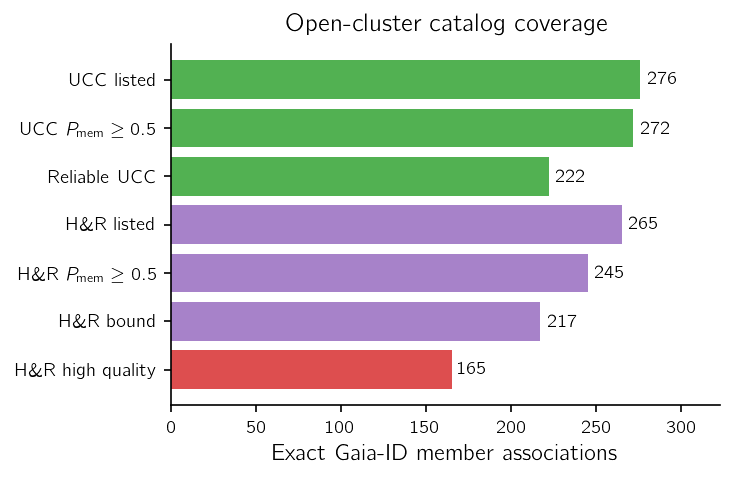

In [5]:
coverage_rows = [
    ("UCC listed", int(boolean(membership, "ucc_listed_member").sum()), COLOR_UCC),
    (r"UCC $P_{\rm mem}\geq0.5$", int(boolean(membership, "ucc_p50_member").sum()), COLOR_UCC),
    ("Reliable UCC", int(boolean(membership, "ucc_good_member").sum()), COLOR_UCC),
    (r"H\&R listed", int(boolean(membership, "hr24_listed_member").sum()), COLOR_HR),
    (r"H\&R $P_{\rm mem}\geq0.5$", int(boolean(membership, "hr24_p50_member").sum()), COLOR_HR),
    (r"H\&R bound", int(boolean(membership, "hr24_bound_member").sum()), COLOR_HR),
    (r"H\&R high quality", int(boolean(membership, "hr24_high_quality_member").sum()), COLOR_HQ),
]
coverage = pd.DataFrame(coverage_rows, columns=["definition", "count", "color"])

with plt.rc_context(PUBLICATION_STYLE):
    fig, ax = plt.subplots(figsize=(5.0, 3.3))
    y = np.arange(len(coverage))
    ax.barh(y, coverage["count"], color=coverage["color"], alpha=0.82)
    ax.set_yticks(y, coverage["definition"])
    ax.invert_yaxis()
    ax.set_xlabel("Exact Gaia-ID member associations")
    ax.set_title("Open-cluster catalog coverage")
    ax.set_xlim(0, float(coverage["count"].max()) * 1.17)
    for yi, value in zip(y, coverage["count"], strict=True):
        ax.text(value + 4, yi, f"{value:,}", va="center", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    figure_paths["catalog_coverage"] = save_figure(fig, "catalog_membership_coverage")
    plt.show()

coverage.drop(columns="color").to_csv(OUTPUT_ROOT / "catalog_membership_coverage.csv", index=False)

,All sources,Reviewed dippers
UCC only,64,6
Both,158,12
H\&R only,59,5


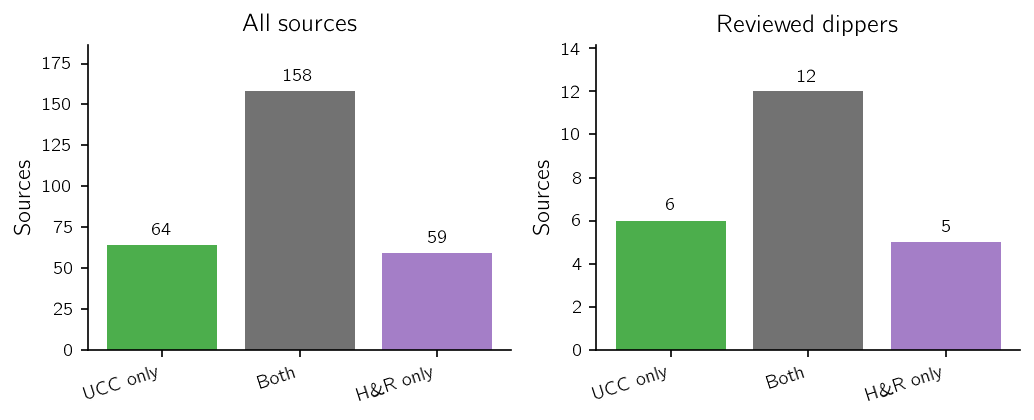

In [6]:
reviewed = membership.merge(labels[["candidate_id", "event_class"]], on="candidate_id", how="inner")
dippers = reviewed.loc[reviewed["event_class"].eq("dipper")].copy()

def overlap_counts(frame: pd.DataFrame) -> dict[str, int]:
    ucc = boolean(frame, "ucc_good_member")
    hr = boolean(frame, "hr24_bound_member")
    return {
        "UCC only": int((ucc & ~hr).sum()),
        "Both": int((ucc & hr).sum()),
        r"H\&R only": int((~ucc & hr).sum()),
    }

overlap = pd.DataFrame({"All sources": overlap_counts(membership), "Reviewed dippers": overlap_counts(dippers)})
display(overlap)

with plt.rc_context(PUBLICATION_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.9))
    colors = [COLOR_UCC, "0.35", COLOR_HR]
    for ax, column in zip(axes, overlap.columns, strict=True):
        values = overlap[column]
        bars = ax.bar(np.arange(len(values)), values, color=colors, alpha=0.85)
        ax.set_xticks(np.arange(len(values)), values.index, rotation=18, ha="right")
        ax.set_ylabel("Sources")
        ax.set_title(column)
        ax.spines[["top", "right"]].set_visible(False)
        ax.bar_label(bars, padding=3, fontsize=9)
        ax.set_ylim(0, max(values.max() * 1.18, 1))
    fig.tight_layout()
    figure_paths["catalog_overlap"] = save_figure(fig, "ucc_hr24_membership_overlap")
    plt.show()

overlap.to_csv(OUTPUT_ROOT / "ucc_hr24_membership_overlap.csv")

## Matched membership enrichment

Bars show observed membership fractions with Wilson 95% intervals. The forest plot reports the prespecified matched Mantel--Haenszel odds ratio and matched-set bootstrap interval. The annotation gives the within-set label-permutation probability.

,outcome,definition,role,positive,total,rate,ci_low,ci_high
0,ucc_good_member,Reliable UCC,Dippers,17,126,0.134921,0.085974,0.205470
1,ucc_good_member,Reliable UCC,Controls,12,321,0.037383,0.021512,0.064196
2,hr24_bound_member,H\&R bound,Dippers,14,126,0.111111,0.067350,0.177884
3,hr24_bound_member,H\&R bound,Controls,14,321,0.043614,0.026155,0.071867
4,hr24_high_quality_member,H\&R high quality,Dippers,13,126,0.103175,0.061292,0.168538
5,hr24_high_quality_member,H\&R high quality,Controls,11,321,0.034268,0.019240,0.060311


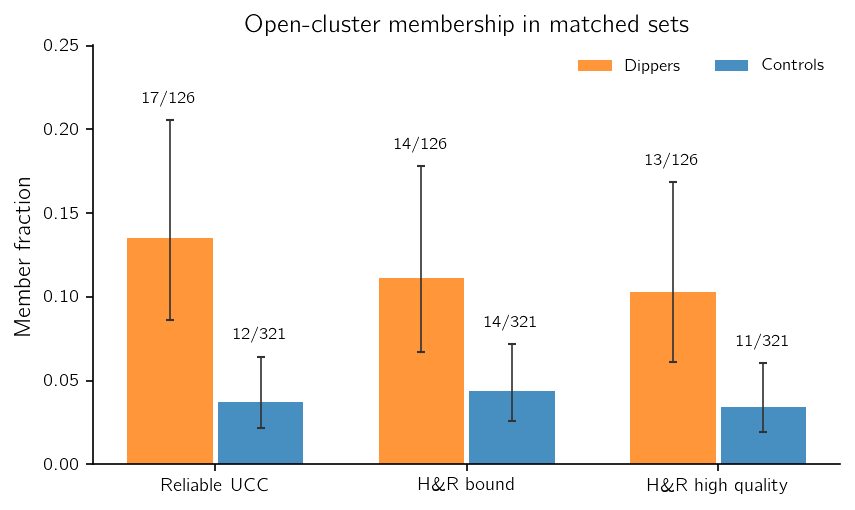

In [7]:
rate_rows = []
for outcome in OUTCOME_LABELS:
    for role, role_label in (("case", "Dippers"), ("control", "Controls")):
        subset = matched.loc[matched["match_role"].eq(role)]
        positive = int(boolean(subset, outcome).sum())
        total = int(len(subset))
        low, high = wilson_interval(positive, total)
        rate_rows.append({
            "outcome": outcome, "definition": OUTCOME_LABELS[outcome],
            "role": role_label, "positive": positive, "total": total,
            "rate": positive / total, "ci_low": low, "ci_high": high,
        })
rates = pd.DataFrame(rate_rows)
display(rates)

with plt.rc_context(PUBLICATION_STYLE):
    fig, ax = plt.subplots(figsize=(5.8, 3.5))
    base = np.arange(len(OUTCOME_LABELS), dtype=float)
    for offset, role, color in ((-0.18, "Dippers", COLOR_CASE), (0.18, "Controls", COLOR_CONTROL)):
        rows = rates.loc[rates["role"].eq(role)].set_index("outcome").loc[list(OUTCOME_LABELS)]
        heights = rows["rate"].to_numpy()
        lower = heights - rows["ci_low"].to_numpy()
        upper = rows["ci_high"].to_numpy() - heights
        bars = ax.bar(base + offset, heights, width=0.34, color=color, alpha=0.82, label=role)
        ax.errorbar(base + offset, heights, yerr=np.vstack([lower, upper]), fmt="none", ecolor="0.2", capsize=2, lw=0.8)
        for bar, (_, row) in zip(bars, rows.iterrows(), strict=True):
            ax.text(bar.get_x() + bar.get_width() / 2, row["ci_high"] + 0.008, f"{int(row['positive'])}/{int(row['total'])}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(base, [OUTCOME_LABELS[key] for key in OUTCOME_LABELS])
    ax.set_ylabel("Member fraction")
    ax.set_title("Open-cluster membership in matched sets")
    ax.set_ylim(0, max(0.20, float(rates["ci_high"].max()) + 0.045))
    ax.legend(frameon=False, ncol=2)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    figure_paths["matched_rates"] = save_figure(fig, "matched_membership_rates")
    plt.show()

rates.to_csv(OUTPUT_ROOT / "matched_membership_rates.csv", index=False)

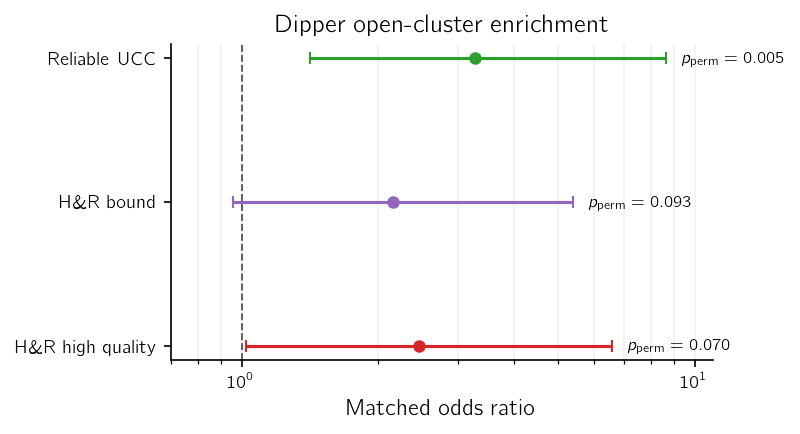

In [8]:
forest = statistics.set_index("outcome").loc[list(OUTCOME_LABELS)].reset_index()
forest["label"] = forest["outcome"].map(OUTCOME_LABELS)

with plt.rc_context(PUBLICATION_STYLE):
    fig, ax = plt.subplots(figsize=(5.4, 3.0))
    y = np.arange(len(forest))[::-1]
    estimate = forest["mantel_haenszel_odds_ratio"].to_numpy(dtype=float)
    low = forest["bootstrap_ci95_low"].to_numpy(dtype=float)
    high = forest["bootstrap_ci95_high"].to_numpy(dtype=float)
    colors = [COLOR_UCC, COLOR_HR, COLOR_HQ]
    for yi, value, lo, hi, color in zip(y, estimate, low, high, colors, strict=True):
        ax.errorbar(value, yi, xerr=[[value - lo], [hi - value]], fmt="o", color=color, ecolor=color, capsize=3, ms=5)
    ax.axvline(1.0, color="0.35", ls="--", lw=0.9)
    ax.set_xscale("log")
    ax.set_xlim(0.7, 11.0)
    ax.set_yticks(y, forest["label"])
    ax.set_xlabel("Matched odds ratio")
    ax.set_title("Dipper open-cluster enrichment")
    for yi, hi, p_value in zip(y, high, forest["matched_permutation_p"], strict=True):
        ax.text(hi * 1.08, yi, rf"$p_{{\rm perm}}={p_value:.3f}$", va="center", fontsize=8)
    ax.grid(axis="x", which="both", alpha=0.18)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    figure_paths["odds_ratios"] = save_figure(fig, "matched_odds_ratio_forest")
    plt.show()

## Matching diagnostics

Absolute standardized differences summarize balance before and after matching. Galactic longitude is represented by sine and cosine to avoid a discontinuity at 0/360 degrees.

,covariate,label,Before matching,After matching
0,match_g_mag,Gaia $G$,0.208874,0.136970
1,match_log_distance,$\ln d$,0.213054,0.077243
2,match_abs_gal_b,$|b|$,0.202297,0.153228
3,match_sin_gal_l,$\sin l$,0.317891,0.162101
4,match_cos_gal_l,$\cos l$,0.186385,0.102976


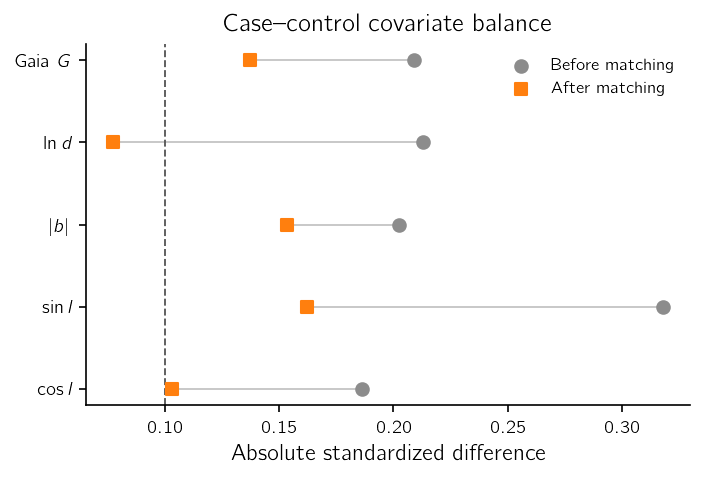

In [9]:
eligible = population.loc[population["match_eligible"] & (population["is_case"] | population["is_control"])].copy()
for frame in (eligible, matched):
    frame["match_log_distance"] = np.log(frame["match_distance_pc"])
    frame["match_abs_gal_b"] = frame["match_gal_b"].abs()
    frame["match_sin_gal_l"] = np.sin(np.deg2rad(frame["match_gal_l"]))
    frame["match_cos_gal_l"] = np.cos(np.deg2rad(frame["match_gal_l"]))

covariates = {
    "match_g_mag": r"Gaia $G$",
    "match_log_distance": r"$\ln d$",
    "match_abs_gal_b": r"$|b|$",
    "match_sin_gal_l": r"$\sin l$",
    "match_cos_gal_l": r"$\cos l$",
}
balance_rows = []
for column, label in covariates.items():
    balance_rows.append({
        "covariate": column, "label": label,
        "Before matching": abs(standardized_difference(eligible.loc[eligible["is_case"], column], eligible.loc[eligible["is_control"], column])),
        "After matching": abs(standardized_difference(matched.loc[matched["match_role"].eq("case"), column], matched.loc[matched["match_role"].eq("control"), column])),
    })
balance = pd.DataFrame(balance_rows)
display(balance)

with plt.rc_context(PUBLICATION_STYLE):
    fig, ax = plt.subplots(figsize=(4.8, 3.3))
    y = np.arange(len(balance))[::-1]
    ax.scatter(balance["Before matching"], y, color=COLOR_NEUTRAL, marker="o", label="Before matching", zorder=3)
    ax.scatter(balance["After matching"], y, color=COLOR_CASE, marker="s", label="After matching", zorder=3)
    for yi, before, after in zip(y, balance["Before matching"], balance["After matching"], strict=True):
        ax.plot([before, after], [yi, yi], color="0.75", lw=0.8, zorder=1)
    ax.axvline(0.1, color="0.35", ls="--", lw=0.9)
    ax.set_yticks(y, balance["label"])
    ax.set_xlabel("Absolute standardized difference")
    ax.set_title("Case--control covariate balance")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    figure_paths["covariate_balance"] = save_figure(fig, "matched_covariate_balance")
    plt.show()

balance.to_csv(OUTPUT_ROOT / "matched_covariate_balance.csv", index=False)

## Sky distribution, membership probability, and age

The sky panel checks whether member dippers are concentrated in a few directions. Probability and age panels show the small-sample distributions directly rather than smoothing them into inferred population densities.

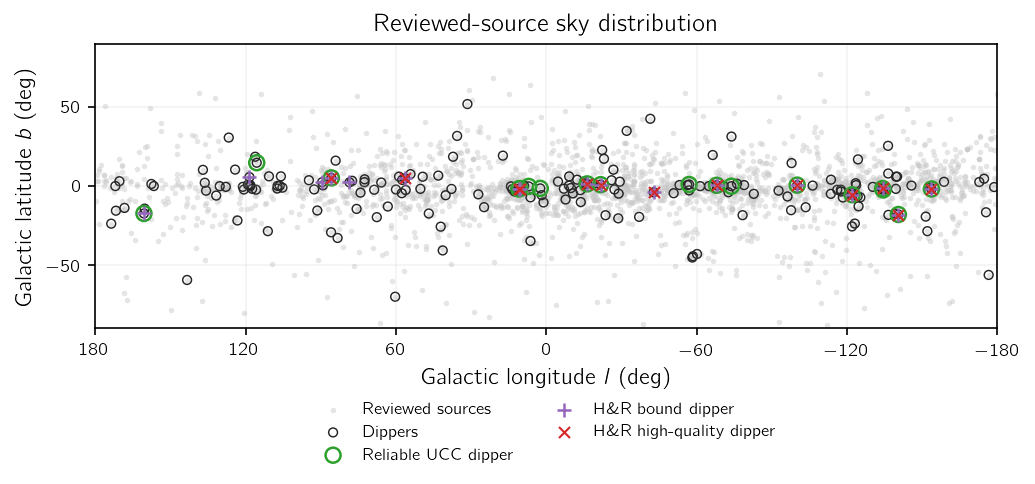

In [10]:
sky = population.loc[population["match_gal_l"].notna() & population["match_gal_b"].notna()].copy()
sky["plot_l"] = ((sky["match_gal_l"] + 180.0) % 360.0) - 180.0
sky_cases = sky.loc[sky["is_case"]].copy()

with plt.rc_context(PUBLICATION_STYLE):
    fig, ax = plt.subplots(figsize=(7.0, 3.5))
    ax.scatter(sky["plot_l"], sky["match_gal_b"], s=7, color="0.78", alpha=0.45, linewidths=0, label="Reviewed sources")
    ax.scatter(sky_cases["plot_l"], sky_cases["match_gal_b"], s=18, facecolors="none", edgecolors="0.15", linewidths=0.7, label="Dippers")
    ucc_cases = sky_cases.loc[boolean(sky_cases, "ucc_good_member")]
    hr_cases = sky_cases.loc[boolean(sky_cases, "hr24_bound_member")]
    hq_cases = sky_cases.loc[boolean(sky_cases, "hr24_high_quality_member")]
    ax.scatter(ucc_cases["plot_l"], ucc_cases["match_gal_b"], s=52, marker="o", facecolors="none", edgecolors=COLOR_UCC, linewidths=1.2, label="Reliable UCC dipper")
    ax.scatter(hr_cases["plot_l"], hr_cases["match_gal_b"], s=44, marker="+", color=COLOR_HR, linewidths=1.2, label=r"H\&R bound dipper")
    ax.scatter(hq_cases["plot_l"], hq_cases["match_gal_b"], s=28, marker="x", color=COLOR_HQ, linewidths=1.0, label=r"H\&R high-quality dipper")
    ax.set_xlim(180, -180)
    ax.set_ylim(-90, 90)
    ax.set_xticks([180, 120, 60, 0, -60, -120, -180])
    ax.set_xlabel(r"Galactic longitude $l$ (deg)")
    ax.set_ylabel(r"Galactic latitude $b$ (deg)")
    ax.set_title("Reviewed-source sky distribution")
    ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.21))
    ax.grid(alpha=0.15)
    fig.tight_layout()
    figure_paths["sky_distribution"] = save_figure(fig, "open_cluster_member_sky_distribution")
    plt.show()

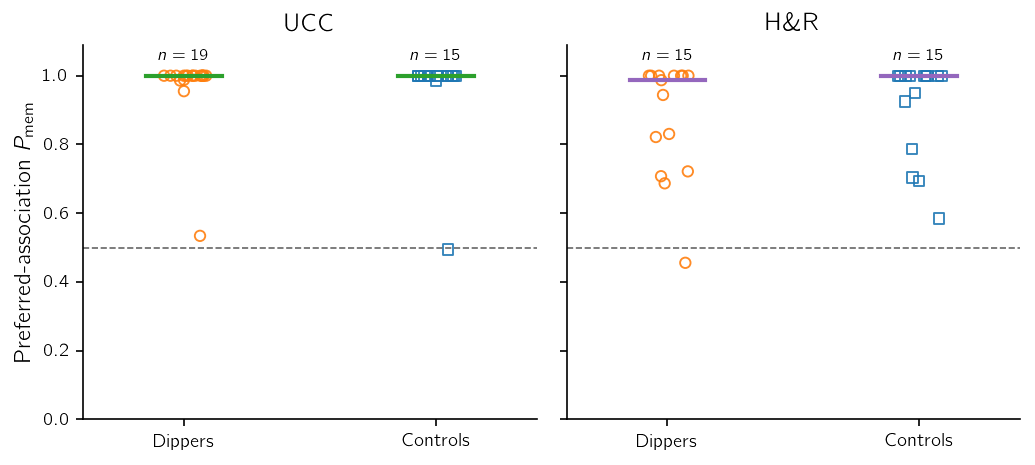

In [11]:
probability_specs = [
    ("ucc_pmem", "ucc_listed_member", "UCC", COLOR_UCC),
    ("hr24_pmem", "hr24_listed_member", r"H\&R", COLOR_HR),
]
rng = np.random.default_rng(20260809)
with plt.rc_context(PUBLICATION_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2), sharey=True)
    for ax, (probability, listed, title, catalog_color) in zip(axes, probability_specs, strict=True):
        for xpos, role, label, marker in ((0, "case", "Dippers", "o"), (1, "control", "Controls", "s")):
            subset = matched.loc[matched["match_role"].eq(role) & boolean(matched, listed)]
            values = pd.to_numeric(subset[probability], errors="coerce").dropna().to_numpy(dtype=float)
            jitter = rng.uniform(-0.09, 0.09, size=len(values))
            color = COLOR_CASE if role == "case" else COLOR_CONTROL
            ax.scatter(np.full(len(values), xpos) + jitter, values, s=25, marker=marker, facecolors="none", edgecolors=color, linewidths=0.9, alpha=0.9)
            if values.size:
                ax.plot([xpos - 0.15, xpos + 0.15], [np.median(values)] * 2, color=catalog_color, lw=2.0)
            ax.text(xpos, 1.035, f"$n={len(values)}$", ha="center", va="bottom", fontsize=8)
        ax.axhline(0.5, color="0.4", ls="--", lw=0.8)
        ax.set_xticks([0, 1], ["Dippers", "Controls"])
        ax.set_xlim(-0.4, 1.4)
        ax.set_ylim(0, 1.09)
        ax.set_title(title)
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].set_ylabel(r"Preferred-association $P_{\rm mem}$")
    fig.tight_layout()
    figure_paths["membership_probabilities"] = save_figure(fig, "matched_membership_probabilities")
    plt.show()

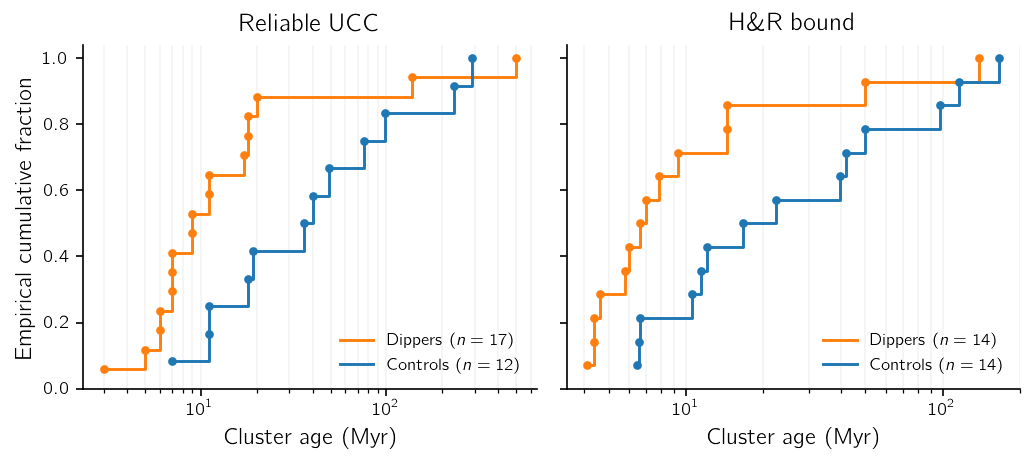

In [12]:
age_specs = [
    ("ucc_age_myr", "ucc_good_member", "Reliable UCC"),
    ("hr24_log_age_yr", "hr24_bound_member", r"H\&R bound"),
]
with plt.rc_context(PUBLICATION_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2), sharey=True)
    for ax, (age_column, member_column, title) in zip(axes, age_specs, strict=True):
        for role, label, color in (("case", "Dippers", COLOR_CASE), ("control", "Controls", COLOR_CONTROL)):
            subset = matched.loc[matched["match_role"].eq(role) & boolean(matched, member_column)]
            values = pd.to_numeric(subset[age_column], errors="coerce").dropna().to_numpy(dtype=float)
            if age_column == "hr24_log_age_yr":
                values = np.power(10.0, values) / 1.0e6
            values = np.sort(values[np.isfinite(values) & (values > 0)])
            if values.size:
                cumulative = np.arange(1, values.size + 1) / values.size
                ax.step(values, cumulative, where="post", color=color, lw=1.4, label=f"{label} ($n={len(values)}$)")
                ax.scatter(values, cumulative, color=color, s=10, zorder=3)
        ax.set_xscale("log")
        ax.set_xlabel("Cluster age (Myr)")
        ax.set_title(title)
        ax.grid(axis="x", which="both", alpha=0.15)
        ax.legend(frameon=False, loc="lower right")
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].set_ylabel("Empirical cumulative fraction")
    axes[0].set_ylim(0, 1.04)
    fig.tight_layout()
    figure_paths["cluster_ages"] = save_figure(fig, "matched_cluster_age_ecdf")
    plt.show()

## Member dipper audit table

In [13]:
case_members = matched.loc[
    matched["match_role"].eq("case")
    & (
        boolean(matched, "ucc_good_member")
        | boolean(matched, "hr24_bound_member")
    )
].copy()
case_columns = [
    "candidate_id", "asas_sn_id", "ra", "dec",
    "ucc_cluster", "ucc_pmem", "ucc_age_myr", "ucc_uti", "ucc_bad_oc",
    "hr24_cluster", "hr24_pmem", "hr24_cluster_type",
    "hr24_cst", "hr24_cmd_class_median", "hr24_log_age_yr",
    "hr24_bound_member", "hr24_high_quality_member",
]
case_members = case_members[case_columns].sort_values(
    ["hr24_high_quality_member", "hr24_bound_member", "ucc_pmem"],
    ascending=[False, False, False],
)
case_members.to_csv(OUTPUT_ROOT / "matched_dipper_open_cluster_members.csv", index=False)
display(case_members.reset_index(drop=True))

,candidate_id,asas_sn_id,ra,dec,ucc_cluster,ucc_pmem,ucc_age_myr,ucc_uti,ucc_bad_oc,hr24_cluster,hr24_pmem,hr24_cluster_type,hr24_cst,hr24_cmd_class_median,hr24_log_age_yr,hr24_bound_member,hr24_high_quality_member
0,stv_68719676517,68719676517,308.014597,48.321313,cwnu2467,1.000,138.0,0.30,False,CWNU_2467,1.000000,o,6.307362,0.983369,8.140480,True,True
1,stv_438087432036,438087432036,129.431821,-40.272737,fof2221,1.000,9.0,0.41,False,OC_0467,1.000000,o,14.081940,0.933349,6.640269,True,True
2,stv_455267329115,455267329115,253.603613,-41.575540,ngc6231,1.000,7.0,1.00,False,NGC_6231,0.721599,o,30.759779,0.984240,6.640033,True,True
3,stv_266288191401,266288191401,98.102352,4.993824,ngc2244,1.000,5.0,0.93,False,NGC_2244,0.821628,o,24.206177,0.877127,6.613714,True,True
4,stv_489627249934,489627249934,109.547726,-24.795827,ngc2362,1.000,6.0,0.95,False,NGC_2362,0.686849,o,23.968666,0.992882,6.842275,True,True
5,stv_326417838270,326417838270,107.366224,-12.204454,cma08,1.000,18.0,0.38,False,OC_0377,1.000000,o,14.566538,0.999454,7.158872,True,True
6,stv_635656028029,635656028029,225.854772,-63.189476,majaess160,1.000,14.0,0.22,True,Majaess_160,1.000000,o,5.809851,0.512930,7.159832,True,True
7,stv_635655213015,635655213015,170.287718,-60.537053,lisc2337,1.000,500.0,0.13,False,UBC_273,0.987060,o,6.616673,0.995971,7.698402,True,True
8,stv_369367489518,369367489518,273.812473,-20.528809,cwnu1630,1.000,9.0,0.31,False,CWNU_1630,1.000000,o,9.415529,0.997047,6.966042,True,True
9,stv_532577049495,532577049495,274.225251,-20.354881,hsc143,1.000,7.0,0.33,False,HSC_143,1.000000,o,5.807034,0.972037,6.662799,True,True


## All reviewed UCC dippers with $P_{\mathrm{mem}} > 0.5$

The atlas below uses the strict probability threshold requested here. It includes every reviewed dipper above the threshold, regardless of the UCC cluster-quality flags used by the enrichment test. Points passing the native MALCA light-curve quality filter are shown by ASAS-SN band; dashed lines mark the saved dip-event time when it lies within the plotted baseline.

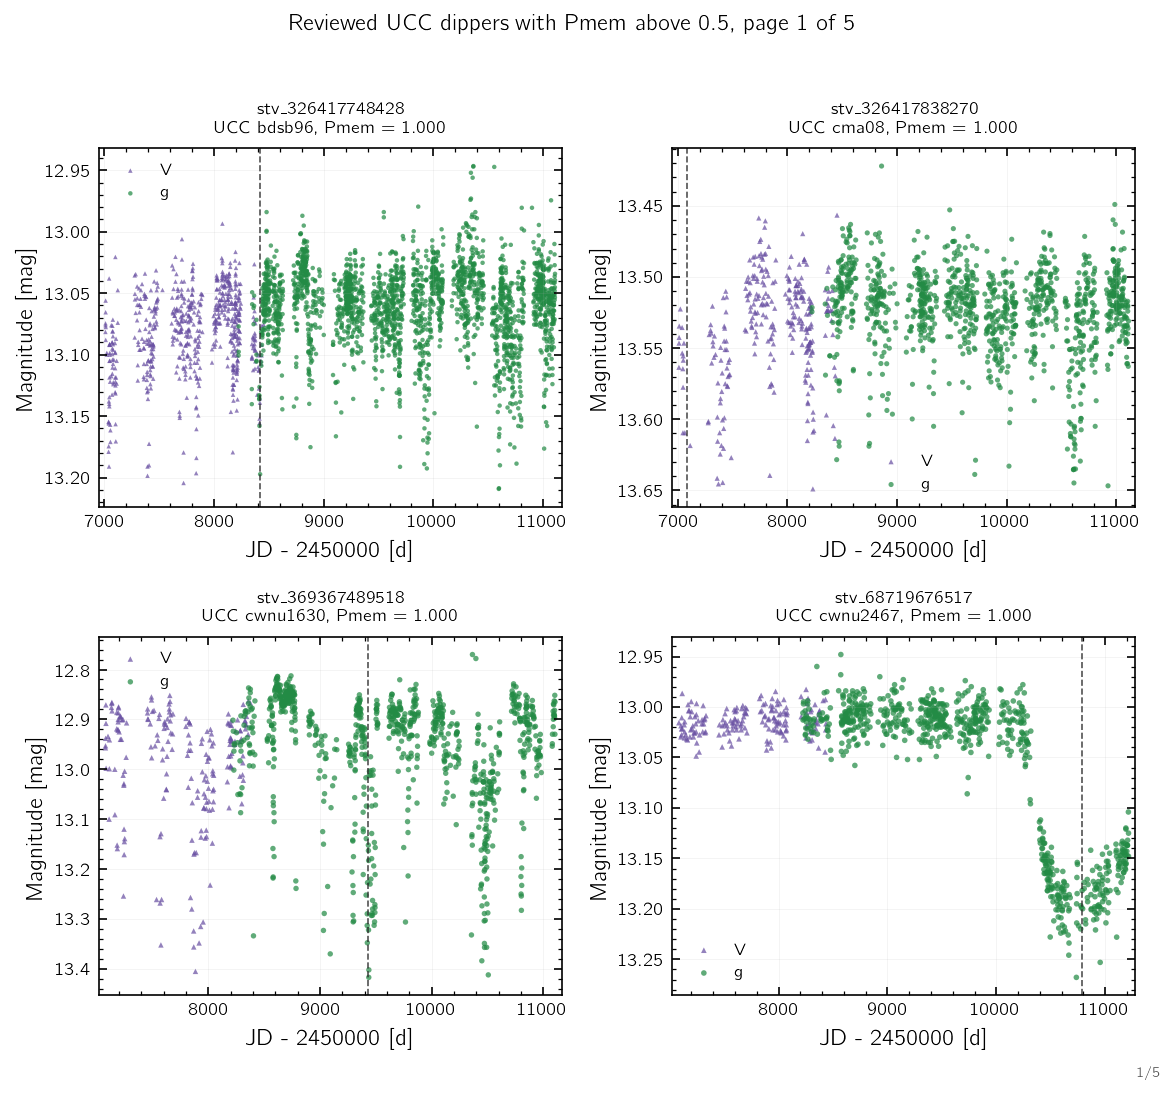

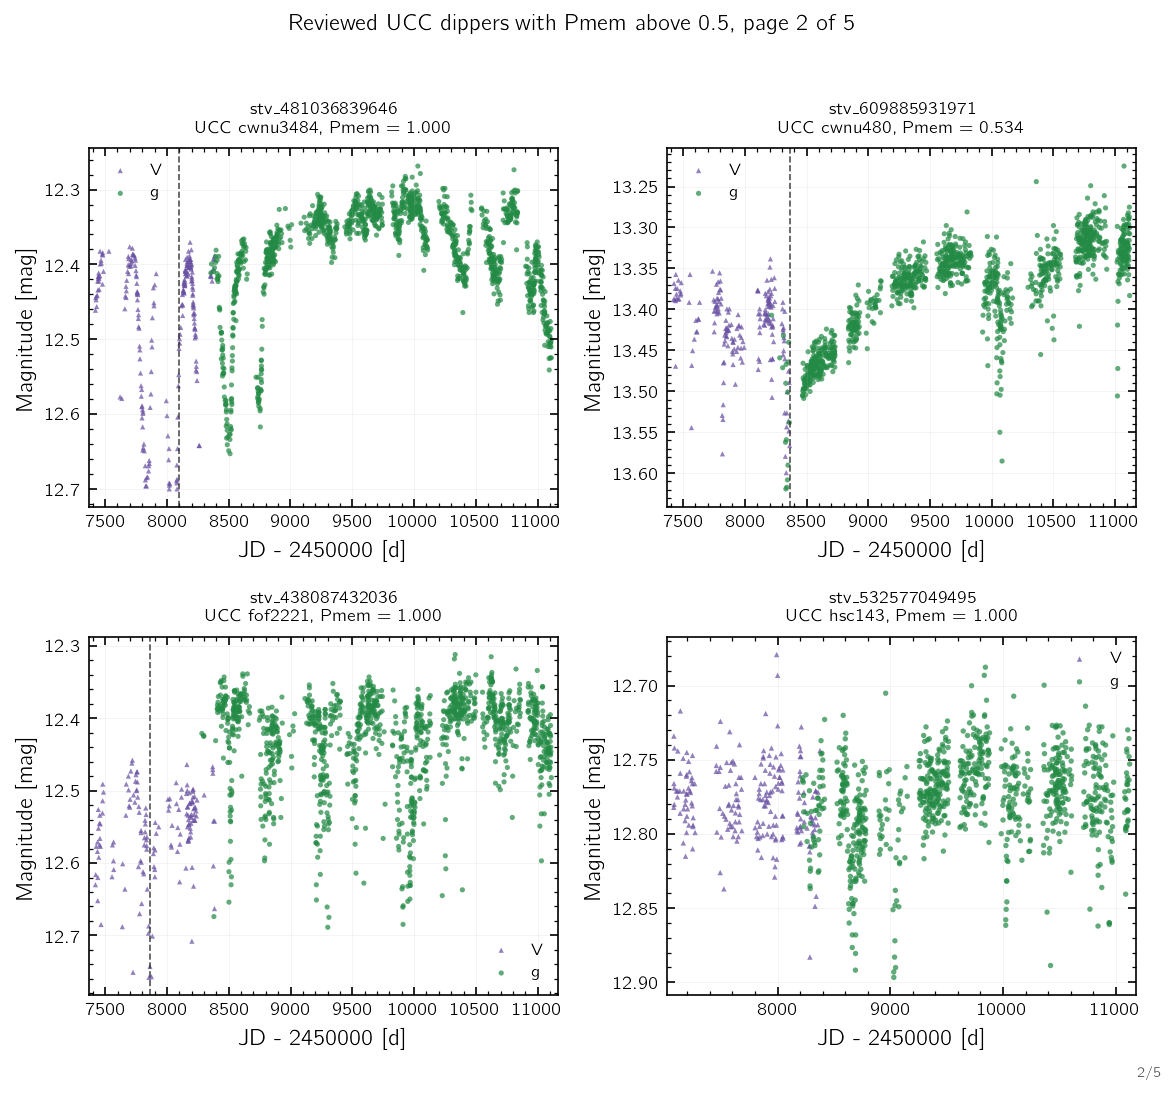

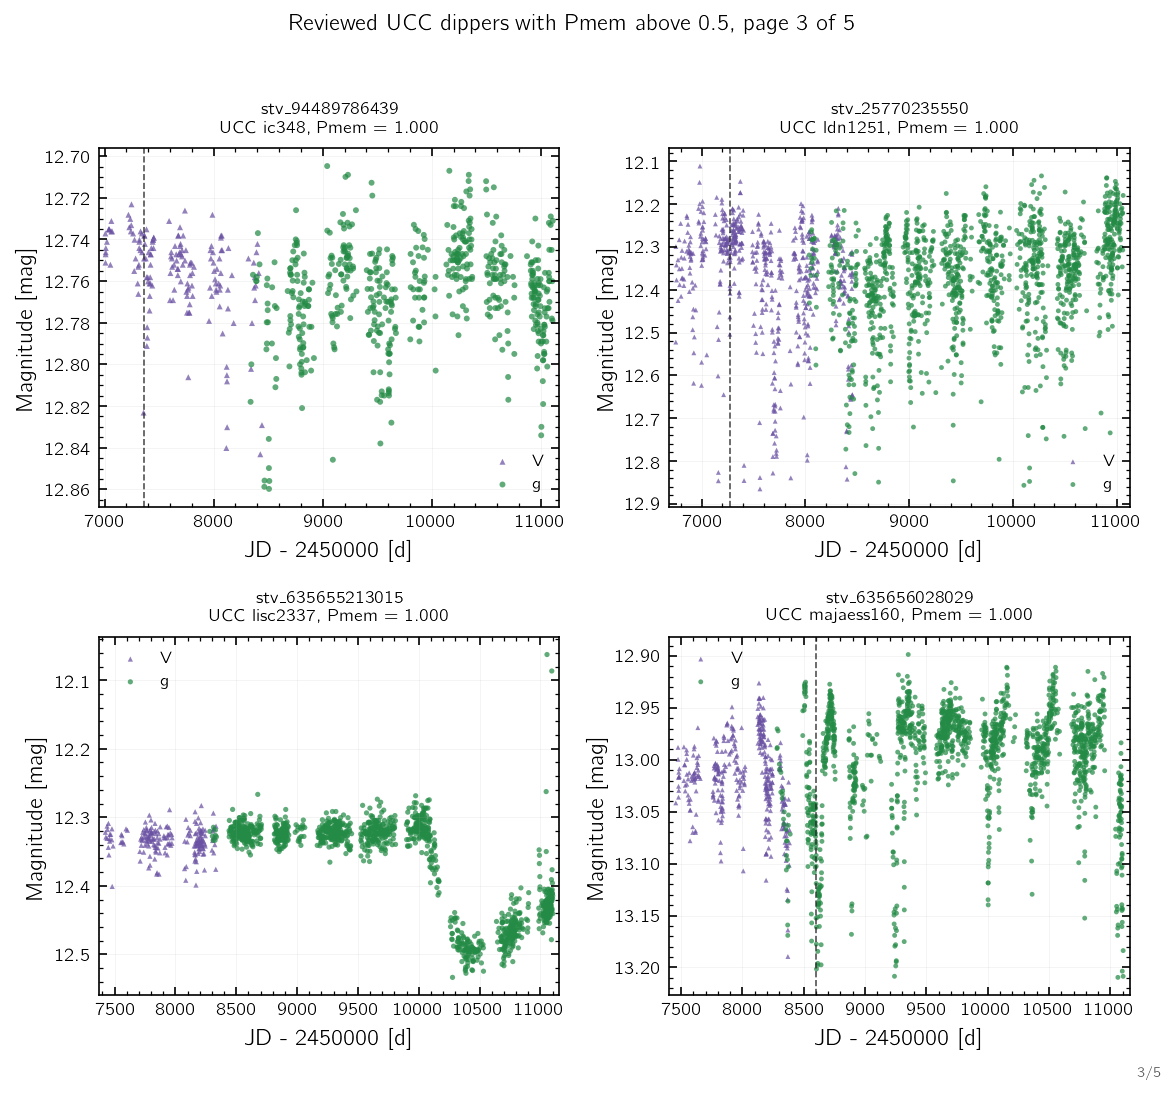

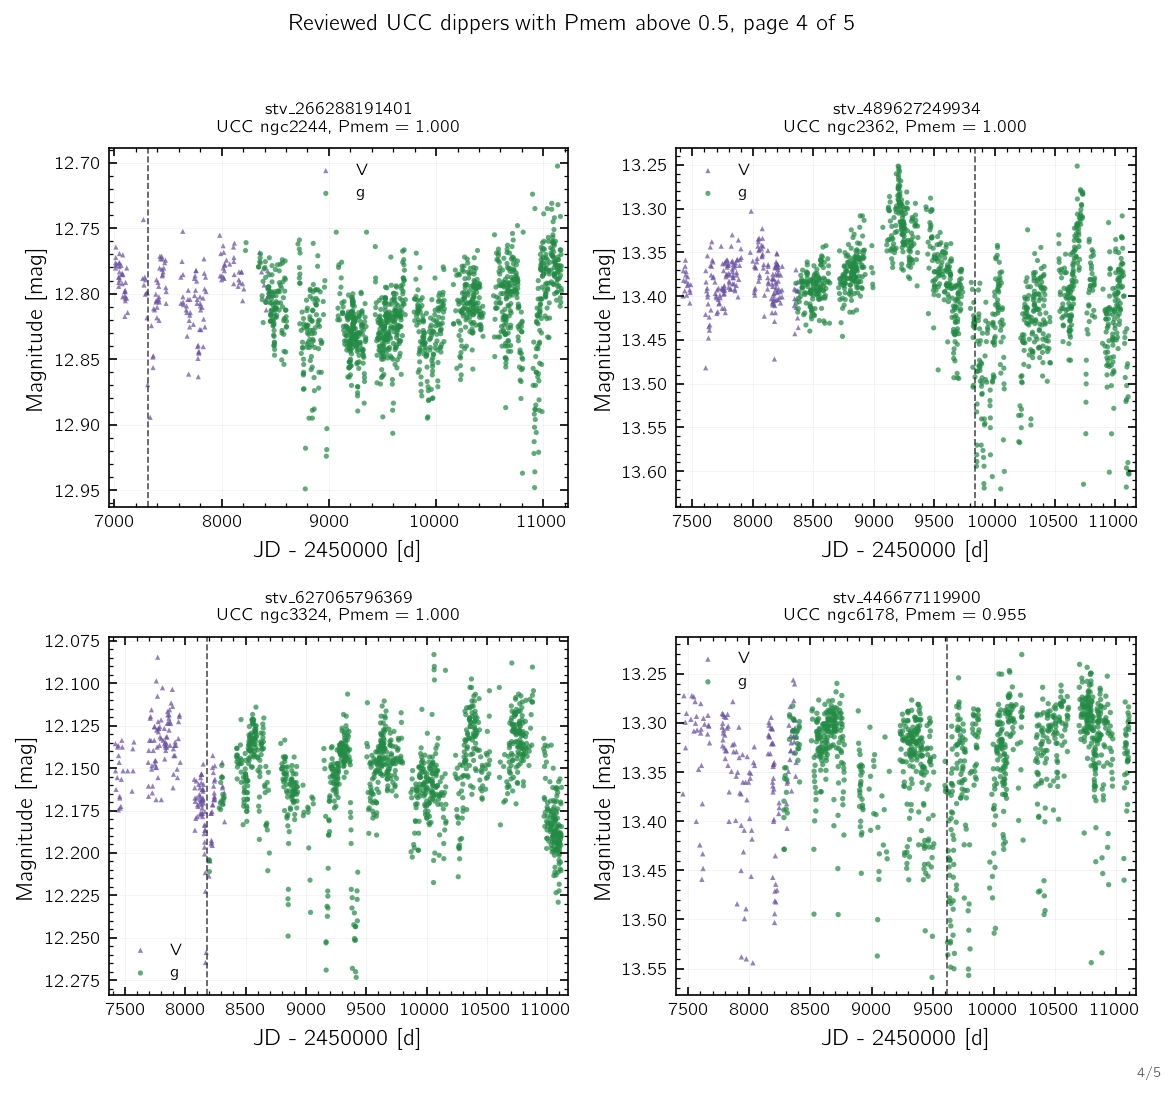

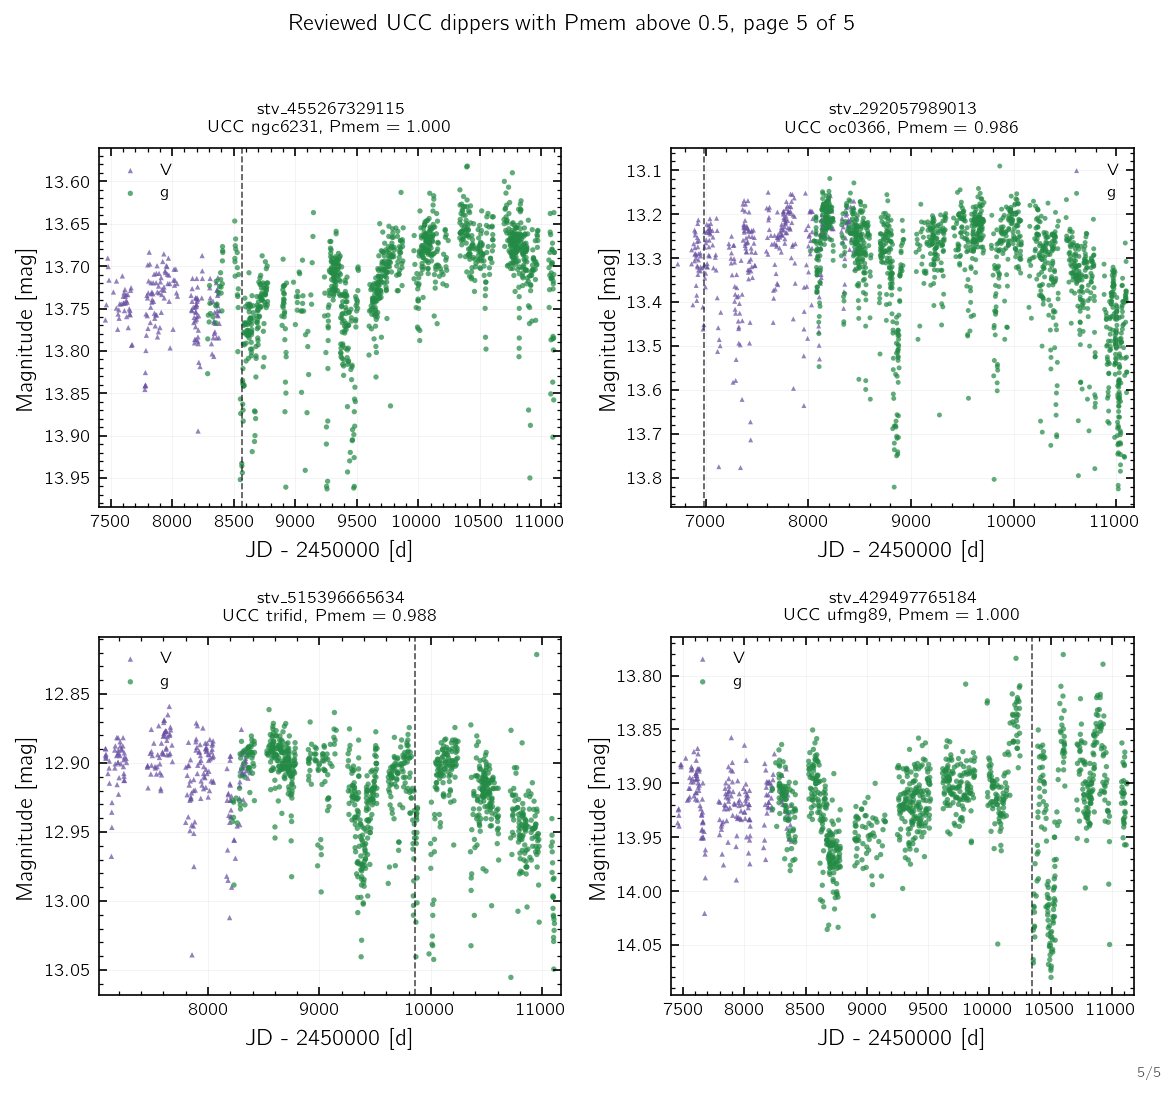

Plotted **20 of 20** reviewed dippers with strict UCC $P_{\mathrm{mem}} > 0.5$ across **5** atlas pages.

,candidate_id,ucc_cluster,ucc_pmem,page,panel,n_quality_points,bands
0,stv_326417748428,bdsb96,1.000,1,1,3011,"V,g"
1,stv_326417838270,cma08,1.000,1,2,1478,"V,g"
2,stv_369367489518,cwnu1630,1.000,1,3,1130,"V,g"
3,stv_68719676517,cwnu2467,1.000,1,4,970,"V,g"
4,stv_481036839646,cwnu3484,1.000,2,1,1513,"V,g"
5,stv_609885931971,cwnu480,0.534,2,2,1420,"V,g"
6,stv_438087432036,fof2221,1.000,2,3,1441,"V,g"
7,stv_532577049495,hsc143,1.000,2,4,1173,"V,g"
8,stv_94489786439,ic348,1.000,3,1,728,"V,g"
9,stv_25770235550,ldn1251,1.000,3,2,1972,"V,g"


In [14]:
ucc_high_probability_dippers = reviewed.loc[
    reviewed["event_class"].eq("dipper")
    & pd.to_numeric(reviewed["ucc_pmem"], errors="coerce").gt(0.5)
].copy()
ucc_high_probability_dippers = ucc_high_probability_dippers.sort_values(
    ["ucc_cluster", "ucc_pmem", "candidate_id"],
    ascending=[True, False, True],
).reset_index(drop=True)

assert not ucc_high_probability_dippers.empty
assert ucc_high_probability_dippers["candidate_id"].astype(str).is_unique
assert boolean(ucc_high_probability_dippers, "ucc_listed_member").all()
assert pd.to_numeric(ucc_high_probability_dippers["ucc_pmem"], errors="raise").gt(0.5).all()

def resolve_ucc_dipper_lightcurve(row: pd.Series) -> Path:
    for value in (row.get("lc_path"), row.get("candidate_id"), row.get("asas_sn_id")):
        resolved = resolve_local_lightcurve_path(value, run_dir=RUN_ROOT, repo_root=ROOT)
        if resolved is not None:
            return resolved
    raise FileNotFoundError(f"No local light curve for {row['candidate_id']}")

PLOTS_PER_PAGE = 4
NROWS, NCOLS = 2, 2
n_pages = math.ceil(len(ucc_high_probability_dippers) / PLOTS_PER_PAGE)
atlas_pdf = PDF_OUTPUT_ROOT / "ucc_pmem_gt_0p5_dipper_lightcurve_atlas.pdf"
atlas_manifest_path = OUTPUT_ROOT / "ucc_pmem_gt_0p5_dipper_lightcurve_manifest.csv"
page_png_paths: list[Path] = []
atlas_rows: list[dict[str, object]] = []

pdf_metadata = {
    "Title": "Reviewed UCC dipper light curves with Pmem > 0.5",
    "Author": "MALCA",
    "Subject": f"All {len(ucc_high_probability_dippers)} reviewed July 1 dippers above the strict UCC threshold",
}
with PdfPages(atlas_pdf, metadata=pdf_metadata) as atlas_writer:
    for page_index in range(n_pages):
        page_number = page_index + 1
        page_rows = ucc_high_probability_dippers.iloc[
            page_index * PLOTS_PER_PAGE : (page_index + 1) * PLOTS_PER_PAGE
        ]
        with plt.rc_context({**PUBLICATION_STYLE, "font.size": 8.0}):
            fig, axes = plt.subplots(NROWS, NCOLS, figsize=(8.0, 7.2), squeeze=False)
            for panel_index, (ax, (_, row)) in enumerate(zip(axes.ravel(), page_rows.iterrows(), strict=False), start=1):
                lc_path = resolve_ucc_dipper_lightcurve(row)
                lc = load_lightcurve_df(lc_path, apply_quality=True)
                if lc.empty:
                    raise ValueError(f"Empty quality-filtered light curve: {lc_path}")

                cluster = str(row["ucc_cluster"])
                pmem = float(row["ucc_pmem"])
                candidate_id = str(row["candidate_id"])
                marker_size = float(np.clip(2.8 * (800.0 / len(lc)) ** 0.20, 1.6, 3.0))
                plot_lightcurve_panel(
                    ax,
                    lc,
                    title=f"{candidate_id}\nUCC {cluster}, Pmem = {pmem:.3f}",
                    group_by="band",
                    color_by="band",
                    marker_by="band",
                    show_errorbars=False,
                    marker_size=marker_size,
                    marker_alpha=0.72,
                    marker_edgecolor=None,
                    marker_edgewidth=0.0,
                    legend="auto",
                    legend_max_groups=4,
                    time_offset="auto",
                    title_fontsize=8.4,
                    margins=(0.015, 0.055),
                    time_col="jd",
                    value_col="mag",
                    error_col="mag_err",
                    band_col="band",
                    camera_col="camera",
                )
                ax.grid(True, linewidth=0.35, alpha=0.18)

                event_t0 = pd.to_numeric(pd.Series([row.get("dip_best_t0")]), errors="coerce").iloc[0]
                if pd.notna(event_t0):
                    event_t0_plot = float(event_t0 - 2_450_000.0 if event_t0 > 2_000_000.0 else event_t0)
                    if min(ax.get_xlim()) <= event_t0_plot <= max(ax.get_xlim()):
                        ax.axvline(event_t0_plot, color="0.15", linestyle="--", linewidth=0.8, alpha=0.8)

                atlas_rows.append({
                    "candidate_id": candidate_id,
                    "asas_sn_id": str(row.get("asas_sn_id", "")),
                    "ucc_cluster": cluster,
                    "ucc_pmem": pmem,
                    "lc_path": str(lc_path),
                    "page": page_number,
                    "panel": panel_index,
                    "n_quality_points": int(len(lc)),
                    "jd_min": float(pd.to_numeric(lc["jd"], errors="coerce").min()),
                    "jd_max": float(pd.to_numeric(lc["jd"], errors="coerce").max()),
                    "bands": ",".join(sorted(lc["band"].dropna().astype(str).unique())),
                })

            for ax in axes.ravel()[len(page_rows):]:
                ax.axis("off")
            fig.suptitle(
                f"Reviewed UCC dippers with Pmem above 0.5, page {page_number} of {n_pages}",
                fontsize=11.0,
                y=0.995,
            )
            fig.text(0.99, 0.008, f"{page_number}/{n_pages}", ha="right", va="bottom", fontsize=7.0, color="0.35")
            fig.tight_layout(rect=(0.02, 0.02, 0.99, 0.965), h_pad=1.8, w_pad=1.1)
            atlas_writer.savefig(fig)
            page_png = OUTPUT_ROOT / f"ucc_pmem_gt_0p5_dipper_lightcurves_page_{page_number:02d}.png"
            fig.savefig(page_png, dpi=240)
            page_png_paths.append(page_png)
            display(fig)
            plt.close(fig)

ucc_dipper_atlas_manifest = pd.DataFrame(atlas_rows)
assert len(ucc_dipper_atlas_manifest) == len(ucc_high_probability_dippers)
assert ucc_dipper_atlas_manifest["candidate_id"].is_unique
assert set(ucc_dipper_atlas_manifest["candidate_id"]) == set(ucc_high_probability_dippers["candidate_id"].astype(str))
assert ucc_dipper_atlas_manifest["n_quality_points"].gt(0).all()
ucc_dipper_atlas_manifest.to_csv(atlas_manifest_path, index=False)
figure_paths["ucc_pmem_gt_0p5_dipper_atlas"] = {
    "pdf": str(atlas_pdf),
    "png_pages": [str(path) for path in page_png_paths],
}

display(Markdown(
    f"Plotted **{len(ucc_dipper_atlas_manifest)} of {len(ucc_high_probability_dippers)}** reviewed dippers with "
    f"strict UCC $P_{{\\mathrm{{mem}}}} > 0.5$ across **{n_pages}** atlas pages."
))
display(ucc_dipper_atlas_manifest[[
    "candidate_id", "ucc_cluster", "ucc_pmem", "page", "panel", "n_quality_points", "bands"
]])

## Physical context and age-dependent dipper diagnostics

These additions connect the strict UCC $P_{\mathrm{mem}} > 0.5$ dipper cohort to dereddened Gaia CMD position, cluster-level physical context, dip depth/duration/recurrence, and age-binned population denominators. UCC membership supplies cluster context rather than an evolutionary classification. The population panel therefore separates the full-run dip-trigger fraction from the selection-biased reviewed-dipper share.

In [15]:
def save_context_figure(figure: plt.Figure, stem: str) -> dict[str, str]:
    pdf = PDF_OUTPUT_ROOT / f"{stem}.pdf"
    png = OUTPUT_ROOT / f"{stem}.png"
    metadata = {"Title": stem.replace("_", " "), "Author": "MALCA"}
    figure.savefig(pdf, metadata=metadata)
    figure.savefig(png, dpi=300)
    return {"pdf": str(pdf), "png": str(png)}

cluster_context_columns = [
    "candidate_id", "asas_sn_id", "ucc_cluster", "ucc_pmem",
    "ucc_good_cluster", "ucc_good_member", "ucc_match_status",
    "ucc_age_myr", "ucc_age_std",
    "ucc_distance_kpc", "ucc_distance_std",
    "ucc_av_mag", "ucc_av_std",
    "ucc_feh_dex", "ucc_feh_std",
    "ucc_mass_msun", "ucc_mass_std", "ucc_n_members",
    "ucc_r50_arcmin", "ucc_core_radius_pc", "ucc_c3",
    "ucc_pdup", "ucc_uti", "ucc_bad_oc",
    "mg0", "bprp0", "mass50", "teff50", "logg50",
    "dip_best_mag_event", "dip_max_run_duration", "dipper_n_valid_dips",
]
cluster_context = ucc_high_probability_dippers[cluster_context_columns].copy()
cluster_context["membership_quality"] = np.where(
    boolean(cluster_context, "ucc_good_member"),
    "reliable UCC",
    "Pmem > 0.5; cluster quality flagged",
)
cluster_context["cmd_complete"] = (
    pd.to_numeric(cluster_context["mg0"], errors="coerce").notna()
    & pd.to_numeric(cluster_context["bprp0"], errors="coerce").notna()
)
cluster_context = cluster_context.sort_values(
    ["ucc_age_myr", "ucc_cluster", "candidate_id"],
    kind="stable",
).reset_index(drop=True)
assert len(cluster_context) == len(ucc_high_probability_dippers) == 20
assert cluster_context["candidate_id"].is_unique
assert cluster_context["ucc_cluster"].nunique() == len(cluster_context)

cluster_context_path = OUTPUT_ROOT / "ucc_pmem_gt_0p5_dipper_cluster_context.csv"
cluster_context.to_csv(cluster_context_path, index=False)
display(Markdown(
    f"The strict cohort contains **{len(cluster_context)} dippers in {cluster_context['ucc_cluster'].nunique()} distinct clusters**. "
    f"**{int(boolean(cluster_context, 'ucc_good_member').sum())}** satisfy the reliable-UCC definition; "
    f"**{int(cluster_context['cmd_complete'].sum())}** have joint dereddened Gaia CMD coordinates."
))
context_display = cluster_context[[
    "candidate_id", "ucc_cluster", "ucc_pmem", "ucc_age_myr",
    "ucc_distance_kpc", "ucc_av_mag", "ucc_feh_dex",
    "ucc_uti", "ucc_bad_oc", "membership_quality", "cmd_complete",
]].copy()
display(context_display.style.format({
    "ucc_pmem": "{:.3f}",
    "ucc_age_myr": "{:.0f}",
    "ucc_distance_kpc": "{:.2f}",
    "ucc_av_mag": "{:.2f}",
    "ucc_feh_dex": "{:.2f}",
    "ucc_uti": "{:.2f}",
}, na_rep="--"))

The strict cohort contains **20 dippers in 20 distinct clusters**. **18** satisfy the reliable-UCC definition; **13** have joint dereddened Gaia CMD coordinates.

,candidate_id,ucc_cluster,ucc_pmem,ucc_age_myr,ucc_distance_kpc,ucc_av_mag,ucc_feh_dex,ucc_uti,ucc_bad_oc,membership_quality,cmd_complete
0,stv_292057989013,oc0366,0.986,3,--,1.80,0.25,0.34,False,reliable UCC,True
1,stv_266288191401,ngc2244,1.000,5,1.45,1.46,-0.20,0.93,False,reliable UCC,True
2,stv_25770235550,ldn1251,1.000,6,--,0.30,--,0.43,False,reliable UCC,True
3,stv_489627249934,ngc2362,1.000,6,1.38,0.35,-0.10,0.95,False,reliable UCC,True
4,stv_627065796369,ngc3324,1.000,6,2.40,1.45,-0.04,0.87,False,reliable UCC,False
5,stv_326417748428,bdsb96,1.000,7,1.15,1.16,-0.14,0.80,False,reliable UCC,True
6,stv_532577049495,hsc143,1.000,7,1.36,0.91,-0.13,0.33,False,reliable UCC,False
7,stv_455267329115,ngc6231,1.000,7,1.43,1.39,0.11,1.00,False,reliable UCC,True
8,stv_369367489518,cwnu1630,1.000,9,1.32,0.87,-0.21,0.31,False,reliable UCC,False
9,stv_438087432036,fof2221,1.000,9,0.93,1.23,-0.06,0.41,False,reliable UCC,False


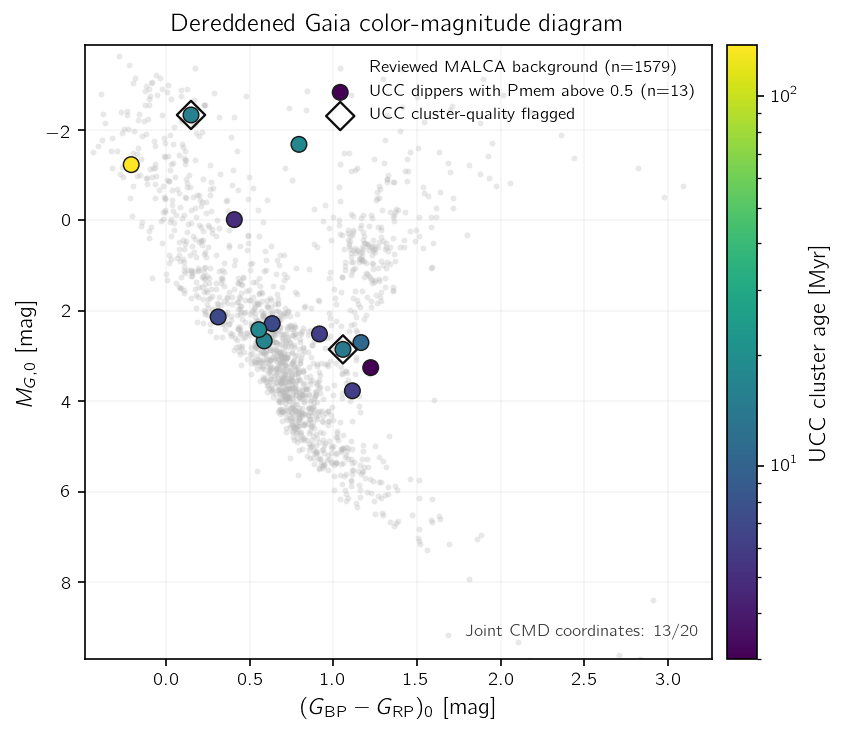

In [16]:
cmd_background = reviewed.copy()
cmd_background["cmd_color"] = pd.to_numeric(cmd_background["bprp0"], errors="coerce")
cmd_background["cmd_abs_g"] = pd.to_numeric(cmd_background["mg0"], errors="coerce")
cmd_background = cmd_background.loc[
    np.isfinite(cmd_background["cmd_color"]) & np.isfinite(cmd_background["cmd_abs_g"])
].copy()
cmd_candidates = cluster_context.loc[cluster_context["cmd_complete"]].copy()
cmd_candidates["cmd_color"] = pd.to_numeric(cmd_candidates["bprp0"], errors="coerce")
cmd_candidates["cmd_abs_g"] = pd.to_numeric(cmd_candidates["mg0"], errors="coerce")
cmd_candidates["cmd_age_myr"] = pd.to_numeric(cmd_candidates["ucc_age_myr"], errors="coerce")
assert len(cmd_candidates) == int(cluster_context["cmd_complete"].sum()) == 13

x_low, x_high = cmd_background["cmd_color"].quantile([0.005, 0.995])
y_low, y_high = cmd_background["cmd_abs_g"].quantile([0.005, 0.995])
x_pad = max(0.15, 0.04 * (x_high - x_low))
y_pad = max(0.35, 0.04 * (y_high - y_low))

with plt.rc_context(PUBLICATION_STYLE):
    fig, ax = plt.subplots(figsize=(5.8, 5.0))
    ax.scatter(
        cmd_background["cmd_color"], cmd_background["cmd_abs_g"],
        s=8, color="0.72", alpha=0.32, linewidths=0, rasterized=True,
        label=f"Reviewed MALCA background (n={len(cmd_background)})",
    )
    age_norm = LogNorm(
        vmin=float(cmd_candidates["cmd_age_myr"].min()),
        vmax=float(cmd_candidates["cmd_age_myr"].max()),
    )
    cmd_points = ax.scatter(
        cmd_candidates["cmd_color"], cmd_candidates["cmd_abs_g"],
        c=cmd_candidates["cmd_age_myr"], cmap="viridis", norm=age_norm,
        s=56, marker="o", edgecolors="0.10", linewidths=0.7, zorder=4,
        label=f"UCC dippers with Pmem above 0.5 (n={len(cmd_candidates)})",
    )
    flagged_cmd = cmd_candidates.loc[~boolean(cmd_candidates, "ucc_good_member")]
    if not flagged_cmd.empty:
        ax.scatter(
            flagged_cmd["cmd_color"], flagged_cmd["cmd_abs_g"],
            s=92, marker="D", facecolors="none", edgecolors="0.05",
            linewidths=1.1, zorder=5, label="UCC cluster-quality flagged",
        )
    colorbar = fig.colorbar(cmd_points, ax=ax, pad=0.02)
    colorbar.set_label("UCC cluster age [Myr]")
    ax.set_xlim(float(x_low - x_pad), float(x_high + x_pad))
    ax.set_ylim(float(y_high + y_pad), float(y_low - y_pad))
    ax.set_xlabel(r"$(G_{\rm BP}-G_{\rm RP})_0$ [mag]")
    ax.set_ylabel(r"$M_{G,0}$ [mag]")
    ax.set_title("Dereddened Gaia color-magnitude diagram")
    ax.text(
        0.98, 0.03, f"Joint CMD coordinates: {len(cmd_candidates)}/{len(cluster_context)}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color="0.25",
    )
    ax.legend(frameon=False, loc="upper right", fontsize=8)
    ax.grid(alpha=0.12)
    fig.tight_layout()
    figure_paths["ucc_dipper_dereddened_cmd"] = save_context_figure(
        fig, "ucc_pmem_gt_0p5_dereddened_gaia_cmd"
    )
    plt.show()

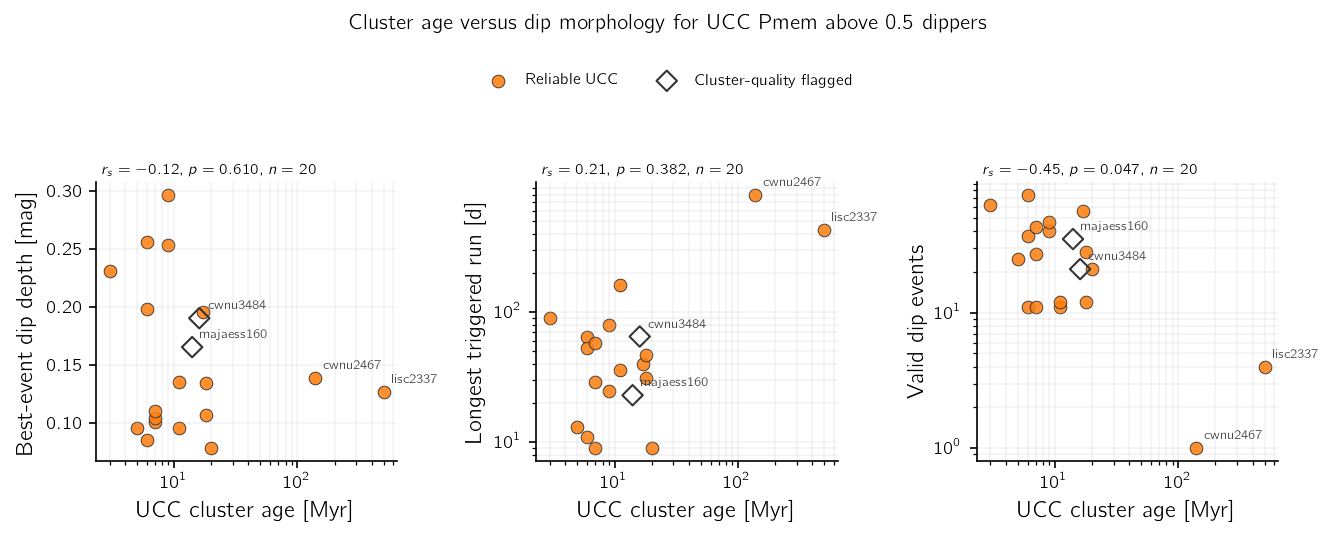

,metric,n,spearman_rho,spearman_p
0,dip_best_mag_event,20,-0.121556,0.609692
1,dip_max_run_duration,20,0.206872,0.381513
2,dipper_n_valid_dips,20,-0.449490,0.046775


In [17]:
morphology_specs = [
    ("dip_best_mag_event", "Best-event dip depth [mag]", "linear"),
    ("dip_max_run_duration", "Longest triggered run [d]", "log"),
    ("dipper_n_valid_dips", "Valid dip events", "log"),
]
morphology_correlations_rows: list[dict[str, object]] = []
with plt.rc_context(PUBLICATION_STYLE):
    fig, axes = plt.subplots(1, 3, figsize=(9.0, 3.55), sharex=True)
    for metric_index, (ax, (metric, ylabel, yscale)) in enumerate(zip(axes, morphology_specs, strict=True)):
        working = cluster_context[["candidate_id", "ucc_cluster", "ucc_age_myr", "ucc_good_member", metric]].copy()
        working["age"] = pd.to_numeric(working["ucc_age_myr"], errors="coerce")
        working["value"] = pd.to_numeric(working[metric], errors="coerce")
        working = working.loc[
            np.isfinite(working["age"]) & working["age"].gt(0)
            & np.isfinite(working["value"]) & working["value"].gt(0)
        ].copy()
        reliable = working.loc[boolean(working, "ucc_good_member")]
        flagged = working.loc[~boolean(working, "ucc_good_member")]
        ax.scatter(
            reliable["age"], reliable["value"], s=37, marker="o",
            color=COLOR_CASE, edgecolors="0.15", linewidths=0.45, alpha=0.88,
            label="Reliable UCC" if metric_index == 0 else None,
        )
        if not flagged.empty:
            ax.scatter(
                flagged["age"], flagged["value"], s=48, marker="D",
                facecolors="none", edgecolors="0.20", linewidths=1.0,
                label="Cluster-quality flagged" if metric_index == 0 else None,
            )
        rho, p_value = spearmanr(working["age"], working["value"])
        morphology_correlations_rows.append({
            "metric": metric, "n": int(len(working)),
            "spearman_rho": float(rho), "spearman_p": float(p_value),
        })
        ax.text(
            0.02, 1.02, f"$r_s={rho:.2f}$, $p={p_value:.3f}$, $n={len(working)}$",
            transform=ax.transAxes, ha="left", va="bottom", fontsize=7.4, clip_on=False,
        )
        annotate = working.loc[(~boolean(working, "ucc_good_member")) | working["age"].ge(100)]
        for _, point in annotate.iterrows():
            ax.annotate(
                str(point["ucc_cluster"]), (point["age"], point["value"]),
                xytext=(4, 4), textcoords="offset points", fontsize=6.3, color="0.25",
            )
        ax.set_xscale("log")
        if yscale == "log":
            ax.set_yscale("log")
        ax.set_xlabel("UCC cluster age [Myr]")
        ax.set_ylabel(ylabel)
        ax.grid(which="both", alpha=0.14)
        ax.spines[["top", "right"]].set_visible(False)
    legend_handles, legend_labels = axes[0].get_legend_handles_labels()
    fig.legend(
        legend_handles, legend_labels, frameon=False, loc="upper center",
        bbox_to_anchor=(0.5, 0.91), ncol=2, fontsize=7.5,
    )
    fig.suptitle("Cluster age versus dip morphology for UCC Pmem above 0.5 dippers", fontsize=10.5, y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.84), w_pad=1.2)
    figure_paths["ucc_dipper_age_morphology"] = save_context_figure(
        fig, "ucc_pmem_gt_0p5_age_morphology"
    )
    plt.show()

morphology_correlations = pd.DataFrame(morphology_correlations_rows)
morphology_correlations_path = OUTPUT_ROOT / "ucc_pmem_gt_0p5_age_morphology_correlations.csv"
morphology_correlations.to_csv(morphology_correlations_path, index=False)
display(morphology_correlations)

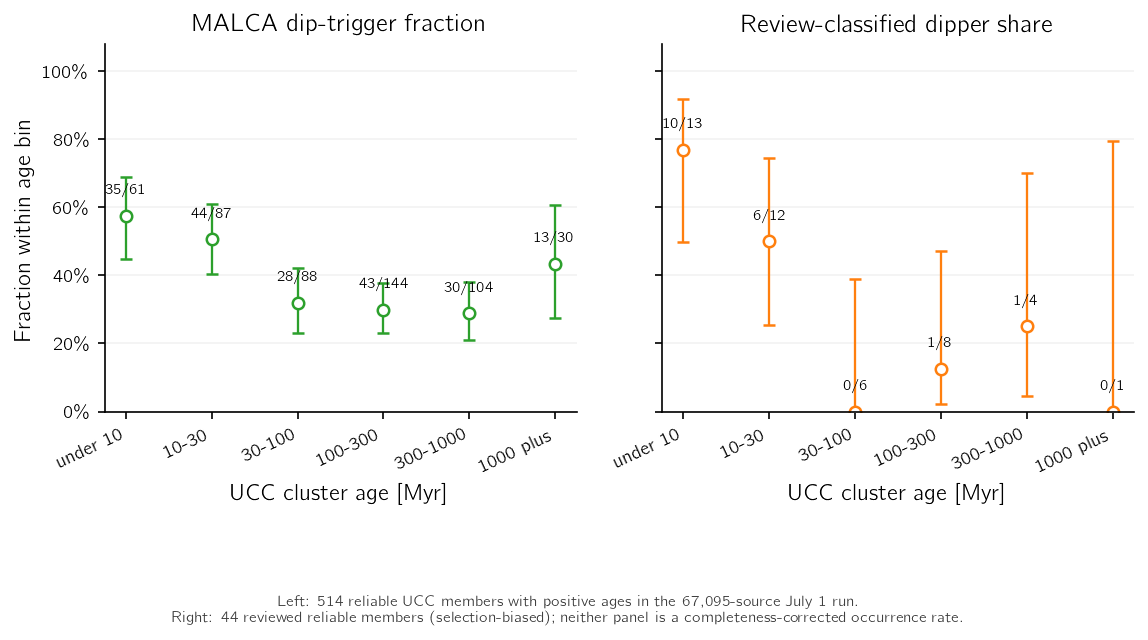

The run-level denominator contains **514 reliable UCC members with ages** out of **67,095 processed July 1 sources**. The left panel measures the pipeline `dip_significant` trigger fraction; the right panel is a reviewed-sample diagnostic, not an occurrence estimate.

,age_bin,age_low_myr,age_high_myr,run_sources,run_dip_triggers,run_trigger_fraction,run_trigger_ci95_low,run_trigger_ci95_high,reviewed_sources,reviewed_dippers,reviewed_dipper_fraction,reviewed_dipper_ci95_low,reviewed_dipper_ci95_high
0,under 10,0.0,10.0,61,35,0.573770,0.448952,0.689848,13,10,0.769231,4.974362e-01,0.918205
1,10-30,10.0,30.0,87,44,0.505747,0.402691,0.608317,12,6,0.500000,2.537816e-01,0.746218
2,30-100,30.0,100.0,88,28,0.318182,0.230226,0.421348,6,0,0.000000,2.775558e-17,0.390334
3,100-300,100.0,300.0,144,43,0.298611,0.229888,0.377800,8,1,0.125000,2.241749e-02,0.470888
4,300-1000,300.0,1000.0,104,30,0.288462,0.210159,0.381835,4,1,0.250000,4.558726e-02,0.699358
5,1000 plus,1000.0,inf,30,13,0.433333,0.273775,0.608027,1,0,0.000000,0.000000e+00,0.793451


In [18]:
full_run_layers = read_feature_table(FULL_RUN_POPULATION_PATH)
full_run_population = expand_feature_layers(full_run_layers)
assert len(full_run_population) == 67_095
assert full_run_population["candidate_id"].astype(str).is_unique
run_population_input = full_run_population[[
    "candidate_id", "gaia_id", "dip_significant",
    "jump_significant", "failed_significant_detection",
]].copy()
run_population_ucc = add_open_cluster_context(
    run_population_input,
    ucc_dir=UCC_DIR,
    hr24_dir=None,
    include_proximity=False,
).sources
assert len(run_population_ucc) == len(full_run_population)

catalog_crosscheck = membership[["candidate_id", "ucc_good_member", "ucc_cluster", "ucc_pmem"]].merge(
    run_population_ucc[["candidate_id", "ucc_good_member", "ucc_cluster", "ucc_pmem"]],
    on="candidate_id", how="inner", suffixes=("_saved", "_recomputed"), validate="one_to_one",
)
assert len(catalog_crosscheck) == len(membership)
assert catalog_crosscheck["ucc_good_member_saved"].fillna(False).astype(bool).equals(
    catalog_crosscheck["ucc_good_member_recomputed"].fillna(False).astype(bool)
)
assert np.allclose(
    pd.to_numeric(catalog_crosscheck["ucc_pmem_saved"], errors="coerce"),
    pd.to_numeric(catalog_crosscheck["ucc_pmem_recomputed"], errors="coerce"),
    equal_nan=True,
)

AGE_BIN_EDGES = np.array([0.0, 10.0, 30.0, 100.0, 300.0, 1000.0, np.inf])
AGE_BIN_LABELS = ["under 10", "10-30", "30-100", "100-300", "300-1000", "1000 plus"]
run_denominator = run_population_ucc.loc[boolean(run_population_ucc, "ucc_good_member")].copy()
run_denominator["cluster_age_myr"] = pd.to_numeric(run_denominator["ucc_age_myr"], errors="coerce")
run_denominator = run_denominator.loc[run_denominator["cluster_age_myr"].gt(0)].copy()
run_denominator["dip_trigger"] = boolean(run_denominator, "dip_significant")
run_denominator["age_bin"] = pd.cut(
    run_denominator["cluster_age_myr"], AGE_BIN_EDGES, labels=AGE_BIN_LABELS, right=False,
)
review_denominator = reviewed.loc[boolean(reviewed, "ucc_good_member")].copy()
review_denominator["cluster_age_myr"] = pd.to_numeric(review_denominator["ucc_age_myr"], errors="coerce")
review_denominator = review_denominator.loc[review_denominator["cluster_age_myr"].gt(0)].copy()
review_denominator["reviewed_dipper"] = review_denominator["event_class"].eq("dipper")
review_denominator["age_bin"] = pd.cut(
    review_denominator["cluster_age_myr"], AGE_BIN_EDGES, labels=AGE_BIN_LABELS, right=False,
)
assert len(run_denominator) > 0 and run_denominator["candidate_id"].is_unique
assert run_denominator["cluster_age_myr"].gt(0).all()
assert len(review_denominator) > 0 and review_denominator["candidate_id"].is_unique

age_bin_rows: list[dict[str, object]] = []
for index, label in enumerate(AGE_BIN_LABELS):
    run_bin = run_denominator.loc[run_denominator["age_bin"].astype(str).eq(label)]
    review_bin = review_denominator.loc[review_denominator["age_bin"].astype(str).eq(label)]
    run_positive = int(run_bin["dip_trigger"].sum())
    review_positive = int(review_bin["reviewed_dipper"].sum())
    run_low, run_high = wilson_interval(run_positive, len(run_bin))
    review_low, review_high = wilson_interval(review_positive, len(review_bin))
    age_bin_rows.append({
        "age_bin": label,
        "age_low_myr": float(AGE_BIN_EDGES[index]),
        "age_high_myr": float(AGE_BIN_EDGES[index + 1]),
        "run_sources": int(len(run_bin)),
        "run_dip_triggers": run_positive,
        "run_trigger_fraction": run_positive / len(run_bin),
        "run_trigger_ci95_low": run_low,
        "run_trigger_ci95_high": run_high,
        "reviewed_sources": int(len(review_bin)),
        "reviewed_dippers": review_positive,
        "reviewed_dipper_fraction": review_positive / len(review_bin),
        "reviewed_dipper_ci95_low": review_low,
        "reviewed_dipper_ci95_high": review_high,
    })
age_bin_summary = pd.DataFrame(age_bin_rows)
age_bin_summary_path = OUTPUT_ROOT / "ucc_age_bin_dip_trigger_and_review_share.csv"
run_denominator_path = OUTPUT_ROOT / "ucc_age_bin_run_population_denominator.csv"
age_bin_summary.to_csv(age_bin_summary_path, index=False)
run_denominator[[
    "candidate_id", "open_cluster_gaia_id", "ucc_cluster", "ucc_pmem",
    "cluster_age_myr", "age_bin", "dip_trigger", "failed_significant_detection",
]].to_csv(run_denominator_path, index=False)

with plt.rc_context(PUBLICATION_STYLE):
    fig, axes = plt.subplots(1, 2, figsize=(8.0, 4.3), sharey=True)
    panel_specs = [
        (axes[0], "run_trigger_fraction", "run_trigger_ci95_low", "run_trigger_ci95_high", "run_dip_triggers", "run_sources", COLOR_UCC, "MALCA dip-trigger fraction"),
        (axes[1], "reviewed_dipper_fraction", "reviewed_dipper_ci95_low", "reviewed_dipper_ci95_high", "reviewed_dippers", "reviewed_sources", COLOR_CASE, "Review-classified dipper share"),
    ]
    xpos = np.arange(len(age_bin_summary))
    for ax, rate_col, low_col, high_col, positive_col, total_col, color, title in panel_specs:
        rate = age_bin_summary[rate_col].to_numpy(dtype=float)
        low = age_bin_summary[low_col].to_numpy(dtype=float)
        high = age_bin_summary[high_col].to_numpy(dtype=float)
        error_lengths = np.vstack([
            np.maximum(rate - low, 0.0),
            np.maximum(high - rate, 0.0),
        ])
        ax.errorbar(
            xpos, rate, yerr=error_lengths,
            fmt="o", color=color, markerfacecolor="white", markeredgewidth=1.2,
            markersize=5.5, capsize=3.0, linewidth=1.1,
        )
        for x, y, positive, total in zip(
            xpos, rate, age_bin_summary[positive_col], age_bin_summary[total_col], strict=True
        ):
            ax.text(x, min(y + 0.055, 1.01), f"{int(positive)}/{int(total)}", ha="center", va="bottom", fontsize=7.2)
        ax.set_xticks(xpos, AGE_BIN_LABELS, rotation=25, ha="right")
        ax.set_xlabel("UCC cluster age [Myr]")
        ax.set_title(title)
        ax.set_ylim(0, 1.08)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.grid(axis="y", alpha=0.16)
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].set_ylabel("Fraction within age bin")
    fig.text(
        0.5, 0.018,
        f"Left: {len(run_denominator)} reliable UCC members with positive ages in the "
        f"{len(full_run_population):,}-source July 1 run.\n"
        f"Right: {len(review_denominator)} reviewed reliable members (selection-biased); "
        f"neither panel is a completeness-corrected occurrence rate.",
        ha="center", va="bottom", fontsize=7.4, color="0.25",
    )
    fig.tight_layout(rect=(0.02, 0.17, 0.99, 1), w_pad=1.5)
    figure_paths["ucc_age_bin_population"] = save_context_figure(
        fig, "ucc_age_bin_dip_trigger_and_review_share"
    )
    plt.show()

display(Markdown(
    f"The run-level denominator contains **{len(run_denominator)} reliable UCC members with ages** out of "
    f"**{len(full_run_population):,} processed July 1 sources**. The left panel measures the pipeline "
    f"`dip_significant` trigger fraction; the right panel is a reviewed-sample diagnostic, not an occurrence estimate."
))
display(age_bin_summary)

## Result summary and output manifest

In [19]:
summary_payload = {
    "tag": TAG,
    "membership_path": str(MEMBERSHIP_PATH),
    "matched_path": str(MATCHED_PATH),
    "review_db": str(REVIEW_DB),
    "review_db_mode": "read_only",
    "source_rows": int(len(membership)),
    "reviewed_dippers": int(population["is_case"].sum()),
    "ucc_pmem_gt_0p5_reviewed_dippers": int(len(ucc_dipper_atlas_manifest)),
    "ucc_pmem_gt_0p5_atlas_pages": int(n_pages),
    "ucc_pmem_gt_0p5_unique_clusters": int(cluster_context["ucc_cluster"].nunique()),
    "ucc_pmem_gt_0p5_joint_cmd_coordinates": int(cluster_context["cmd_complete"].sum()),
    "full_run_population_rows": int(len(full_run_population)),
    "full_run_reliable_ucc_members_with_age": int(len(run_denominator)),
    "reviewed_reliable_ucc_members_with_age": int(len(review_denominator)),
    "age_bin_population_scope": "pipeline dip-trigger fraction in lc_events_filtered_all; not completeness-corrected astrophysical occurrence",
    "matched_dippers": int(matched["match_role"].eq("case").sum()),
    "matched_controls": int(matched["match_role"].eq("control").sum()),
    "post_match_covariates_above_abs_smd_0p1": int(balance["After matching"].gt(0.1).sum()),
    "statistics": statistics.replace({np.nan: None, np.inf: "inf", -np.inf: "-inf"}).to_dict(orient="records"),
    "figures": figure_paths,
    "tables": {
        "coverage": str(OUTPUT_ROOT / "catalog_membership_coverage.csv"),
        "overlap": str(OUTPUT_ROOT / "ucc_hr24_membership_overlap.csv"),
        "matched_rates": str(OUTPUT_ROOT / "matched_membership_rates.csv"),
        "balance": str(OUTPUT_ROOT / "matched_covariate_balance.csv"),
        "member_dippers": str(OUTPUT_ROOT / "matched_dipper_open_cluster_members.csv"),
        "ucc_pmem_gt_0p5_dipper_lightcurves": str(atlas_manifest_path),
        "ucc_pmem_gt_0p5_cluster_context": str(cluster_context_path),
        "ucc_pmem_gt_0p5_age_morphology_correlations": str(morphology_correlations_path),
        "ucc_age_bin_population_summary": str(age_bin_summary_path),
        "ucc_age_bin_run_population_denominator": str(run_denominator_path),
    },
}
summary_path = OUTPUT_ROOT / "notebook_summary.json"
summary_path.write_text(json.dumps(summary_payload, indent=2, sort_keys=True) + "\n", encoding="utf-8")

ucc = statistics.set_index("outcome").loc["ucc_good_member"]
hr_bound = statistics.set_index("outcome").loc["hr24_bound_member"]
hr_hq = statistics.set_index("outcome").loc["hr24_high_quality_member"]
remaining_imbalanced = int(balance["After matching"].gt(0.1).sum())
display(Markdown(
    f"**Primary result.** Reliable UCC membership is enriched among matched dippers "
    f"(OR = {ucc['mantel_haenszel_odds_ratio']:.2f}, 95% bootstrap CI "
    f"{ucc['bootstrap_ci95_low']:.2f}--{ucc['bootstrap_ci95_high']:.2f}, "
    f"matched permutation p = {ucc['matched_permutation_p']:.4f}). "
    f"Hunt--Reffert bound and high-quality definitions point in the same direction "
    f"but have permutation p = {hr_bound['matched_permutation_p']:.3f} and "
    f"{hr_hq['matched_permutation_p']:.3f}, respectively. "
    f"The balance audit retains {remaining_imbalanced} of {len(balance)} covariates above "
    f"an absolute standardized difference of 0.1, so these matched estimates remain exploratory."
))
print(f"Notebook output manifest: {summary_path}")

**Primary result.** Reliable UCC membership is enriched among matched dippers (OR = 3.27, 95% bootstrap CI 1.42--8.65, matched permutation p = 0.0051). Hunt--Reffert bound and high-quality definitions point in the same direction but have permutation p = 0.093 and 0.070, respectively. The balance audit retains 4 of 5 covariates above an absolute standardized difference of 0.1, so these matched estimates remain exploratory.

Notebook output manifest: /Users/calder/code/malca/output/notebooks/open_cluster_membership_enrichment/july1_20260809_ucc_hr24_v1/notebook_summary.json
